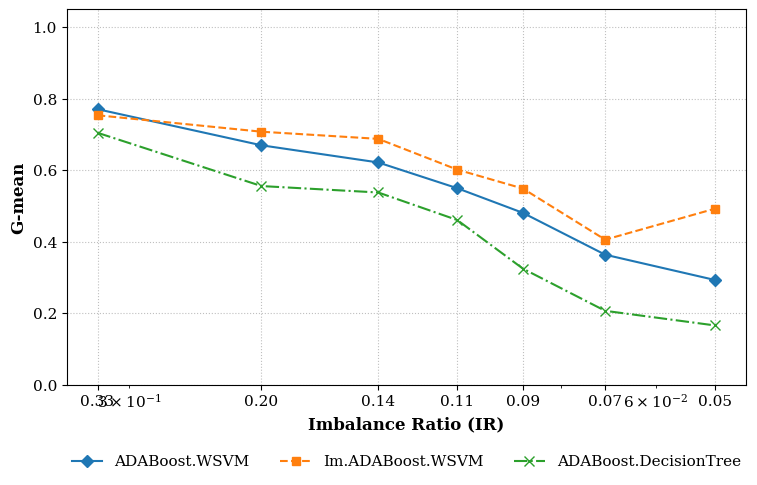

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Cài đặt font chữ chuẩn học thuật (tuỳ chọn, giống font Times New Roman)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 11

# 2. Dữ liệu giả định (Dựa trên hình của bạn)
# Imbalance Ratio (IR) giảm dần
x_ir = [0.33, 0.20, 0.14, 0.11, 0.09, 0.07, 0.05] 
# Bạn có thể dùng mảng string x_labels = ['1/3', '1/5', '1/7'...] để hiển thị đẹp hơn

y_wsvm = [0.771, 0.670, 0.622, 0.550, 0.481, 0.364, 0.293]
y_im_wsvm = [0.754, 0.708, 0.688, 0.602, 0.549, 0.406, 0.493]
y_dtree = [0.705, 0.556, 0.538, 0.461, 0.325, 0.207, 0.166]

# 3. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(8, 5)) # Kích thước chuẩn cho 1 cột báo

# 4. Vẽ các đường (Sử dụng Marker và Linestyle khác nhau để phân biệt khi in trắng đen)
ax.plot(x_ir, y_wsvm, marker='D', markersize=6, linestyle='-', linewidth=1.5, color='#1f77b4', label='ADABoost.WSVM')
ax.plot(x_ir, y_im_wsvm, marker='s', markersize=6, linestyle='--', linewidth=1.5, color='#ff7f0e', label='Im.ADABoost.WSVM')
ax.plot(x_ir, y_dtree, marker='x', markersize=7, linestyle='-.', linewidth=1.5, color='#2ca02c', label='ADABoost.DecisionTree')

# ==========================================
# 5. XỬ LÝ TRỤC X (QUAN TRỌNG NHẤT)
# ==========================================
# Chuyển trục X sang thang đo Logarit để phản ánh đúng khoảng cách toán học của tỷ lệ (Ratios)
ax.set_xscale('log')

# Đảo ngược trục X nếu bạn muốn đi từ Tỷ lệ lớn (0.33) xuống tỷ lệ nhỏ (0.05) như hình cũ
ax.invert_xaxis()

# Ép Matplotlib hiển thị chính xác các mốc IR của bạn thay vì các mốc log mặc định (10^-1, 10^-2)
ax.set_xticks(x_ir)
# Định dạng số hiển thị trên trục X (chỉ lấy 2 số thập phân hoặc dạng phân số tuỳ bạn)
ax.set_xticklabels([f'{val:.2f}' for val in x_ir]) 

# 6. Tuỳ chỉnh lưới và nhãn trục
ax.grid(True, which='major', axis='both', linestyle=':', color='gray', alpha=0.5)
ax.set_xlabel('Imbalance Ratio (IR)', fontsize=12, fontweight='bold')
ax.set_ylabel('G-mean', fontsize=12, fontweight='bold') # Nhớ thay tên metric của bạn
ax.set_ylim(0, 1.05) # Giới hạn trục Y từ 0 đến 1 (nếu là tỷ lệ % hoặc G-mean)

# 7. Xử lý Legend (Chú thích)
# Đặt legend ở dưới cùng, chia làm 3 cột, không viền để tạo sự thoáng đãng
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)

# 8. Căn chỉnh bố cục để không bị cắt chữ
plt.tight_layout()

# 9. Hiển thị / Lưu ảnh (Lưu dpi=300 cho bài báo)
# plt.savefig('my_chart.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()